# Time Regression Model

Predicts the **actual service duration** (in minutes) for a given job order service.

**Features:** estimated_duration_mins, service_id, base_price, base_duration_hours, is_price_fixed, vehicle_age, vehicle_type, mileage

**Target:** actual_duration_mins

> `actual_amount` was intentionally removed from features — it is the real final cost which is only known *after* the service is complete (data leakage).

In [1]:
import pandas as pd
import numpy as np
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


In [2]:
import psycopg2

DB_HOST = "localhost"
DB_USER = "postgres"
DB_PASS = "paduding27"
DB_NAME = "Capstone-Testing"
DB_PORT = "5432"

def load_table_from_db(table_name):
    try:
        conn = psycopg2.connect(host=DB_HOST, user=DB_USER, password=DB_PASS, dbname=DB_NAME, port=DB_PORT)
        query = f'SELECT * FROM "{table_name}"'
        df = pd.read_sql_query(query, conn)
        conn.close()
        return df
    except:
        return pd.DataFrame()

# Combine CSV and DB
tables = ['job_order_services', 'services', 'job_orders', 'vehicles']
combined_dataframes = {}
for table in tables:
    csv_path = f'../../CSV_FILES/{table}.csv'
    
    csv_df = pd.DataFrame()
    if os.path.exists(csv_path):
        try:
            csv_df = pd.read_csv(csv_path)
        except:
            pass
            
    db_df = load_table_from_db(table)
    
    if not csv_df.empty and not db_df.empty:
        combined_dataframes[table] = pd.concat([csv_df, db_df]).drop_duplicates(subset=['id'], keep='last')
    elif not csv_df.empty:
        combined_dataframes[table] = csv_df
    elif not db_df.empty:
        combined_dataframes[table] = db_df
    else:
        print(f"Failed to load {table}")
        
    if table in combined_dataframes:
        print(f"Table: {table}, {len(combined_dataframes[table])} rows (combined CSV+DB)")

dataframes = combined_dataframes


C:\Users\Snow\AppData\Local\Temp\ipykernel_43768\3156801273.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)
C:\Users\Snow\AppData\Local\Temp\ipykernel_43768\3156801273.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)
C:\Users\Snow\AppData\Local\Temp\ipykernel_43768\3156801273.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


Table: job_order_services, 2319 rows (combined CSV+DB)
Table: services, 8 rows (combined CSV+DB)
Table: job_orders, 1375 rows (combined CSV+DB)


Table: vehicles, 1500 rows (combined CSV+DB)


C:\Users\Snow\AppData\Local\Temp\ipykernel_43768\3156801273.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [3]:
# Checking each table
for name, df in dataframes.items():
    print(f"table {name}: {df.shape[0]} rows")
    print(f"Columns: {', '.join(df.columns.tolist())}\n")


table job_order_services: 2319 rows
Columns: id, job_order_id, service_id, description_of_work, estimated_duration, actual_duration, estimated_hours, actual_hours, estimated_amount, actual_amount

table services: 8 rows
Columns: id, shop_id, service_name, description, base_price, base_duration_hours, is_price_fixed, is_active

table job_orders: 1375 rows
Columns: id, ticket_id, user_id, vehicle_id, jo_date, date_arrived, date_promised, started_at, completed_at, released_at, estimated_duration, actual_duration, estimated_grand_total, actual_grand_total, partial_payment, balance, status, quotation_notes, quotation_approved

table vehicles: 1500 rows
Columns: id, user_id, vin, plate_number, vehicle_model, vehicle_year, mileage, vehicle_type



In [4]:
# Change datetime (or time) in string vers to minutes
def durations_to_minutes(duration):
    if pd.isna(duration):
        return np.nan
    
    d = str(duration).strip()
    # "X days HH:MM:SS"
    match = re.match(r'(\d+)\s+days\s+(\d+):(\d+):(\d+)', d)
    if match:
        days, hours, mins, secs = map(int, match.groups())
        return days * 24 * 60 + hours * 60 + mins + (secs/60)
    # "HH:MM:SS"
    match = re.match(r'(\d+):(\d+):(\d+)', d)
    if match:
        hours, mins, secs = map(int, match.groups())
        return hours * 60 + mins + (secs/60)
    return np.nan

# Testing
test_cases = ["0 days 02:30:45", "1 days 00:15:00", "03:45:30"]
for t in test_cases:
    print(f" '{t}' = {durations_to_minutes(t)} minutes")


 '0 days 02:30:45' = 150.75 minutes
 '1 days 00:15:00' = 1455.0 minutes
 '03:45:30' = 225.5 minutes


In [5]:
# Dataframes
job_order_services = dataframes['job_order_services'].copy()
services = dataframes['services'].copy()
job_orders = dataframes['job_orders'].copy()
vehicles = dataframes['vehicles'].copy()

# Parsing
job_order_services['estimated_duration_mins'] = job_order_services['estimated_duration'].apply(durations_to_minutes)
job_order_services['actual_duration_mins']    = job_order_services['actual_duration'].apply(durations_to_minutes)
job_order_services['actual_amount'] = pd.to_numeric(job_order_services['actual_amount'], errors='coerce')

# Merging
full_data = job_order_services.merge(
    services[['id', 'base_price', 'base_duration_hours', 'is_price_fixed']],
    left_on='service_id', right_on='id', how='left', suffixes=('', '_s')
)

full_data = full_data.merge(
    job_orders[['id', 'vehicle_id']].rename(columns={'id': 'jo_id'}),
    left_on='job_order_id', right_on='jo_id', how='left'
)

full_data = full_data.merge(
    vehicles[['id', 'vehicle_year', 'vehicle_type', 'mileage']].rename(columns={'id': 'veh_id'}),
    left_on='vehicle_id', right_on='veh_id', how='left'
)

# vehicle age, mileage & encoder
full_data['vehicle_age'] = pd.Timestamp.now().year - full_data['vehicle_year']
full_data['mileage'] = pd.to_numeric(full_data['mileage'], errors='coerce')
full_data['mileage'] = full_data['mileage'].fillna(full_data['vehicle_age'] * 15000)

veh_type_encoder = LabelEncoder()
full_data['vehicle_type_encoded'] = veh_type_encoder.fit_transform(full_data['vehicle_type'].fillna('Unknown'))

# Features and target
# NOTE: actual_amount REMOVED from features — it is the real final cost which is unknown at prediction time (data leakage).
# Added: mileage (higher mileage vehicles take longer to service)
features = [
    'estimated_duration_mins', 'service_id',
    'base_price', 'base_duration_hours', 'is_price_fixed',
    'vehicle_age', 'vehicle_type_encoded', 'mileage'
]

target = 'actual_duration_mins'

# We must include 'actual_amount' in the dataframe so it can be passed to the cost model (which uses it as a target),
# even though the time model no longer uses it as a feature.
df = full_data[features + [target, 'actual_amount']].dropna()
print(f"Columns: {full_data.columns.tolist()}")
print(f"Rows: {full_data.shape[0]}")
print(f"Target: {target}")
print(f"Analytics:")
df.describe().round(2)


Columns: ['id', 'job_order_id', 'service_id', 'description_of_work', 'estimated_duration', 'actual_duration', 'estimated_hours', 'actual_hours', 'estimated_amount', 'actual_amount', 'estimated_duration_mins', 'actual_duration_mins', 'id_s', 'base_price', 'base_duration_hours', 'is_price_fixed', 'jo_id', 'vehicle_id', 'veh_id', 'vehicle_year', 'vehicle_type', 'mileage', 'vehicle_age', 'vehicle_type_encoded']
Rows: 2319
Target: actual_duration_mins
Analytics:


,estimated_duration_mins,service_id,base_price,base_duration_hours,vehicle_age,vehicle_type_encoded,mileage,actual_duration_mins,actual_amount
count,2315.00,2315.00,2315.00,2315.00,2315.00,2315.00,2315.00,2315.00,2315.00
mean,89.35,2.68,1738.27,1.03,10.62,2.52,85126.22,98.12,2439.92
std,37.21,2.13,880.54,0.37,4.09,1.75,39593.05,41.75,1070.42
min,27.00,1.00,800.00,0.50,2.00,0.00,5179.00,28.50,720.45
25%,60.71,1.00,1500.00,1.00,8.00,1.00,55993.00,64.52,1433.02
50%,95.62,1.00,1500.00,1.00,11.00,3.00,86592.98,103.27,2539.22
75%,121.19,4.00,1500.00,1.00,14.00,4.00,118114.00,133.07,3231.44
max,149.95,8.00,4500.00,2.00,16.00,5.00,149959.79,167.88,5316.89


In [6]:
# Split data
X_time = df[features]
y_time = df[target]

# train_test_split
X_time_train, X_time_test, y_time_train, y_time_test = train_test_split(
    X_time, y_time, test_size=0.2, random_state=27
)

# RandomForestRegressor
rf_time = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_time.fit(X_time_train, y_time_train)

# Train & Test prediction
y_time_pred_train = rf_time.predict(X_time_train)
y_time_pred_test  = rf_time.predict(X_time_test)

# Analytics
mse_train = mean_squared_error(y_time_train, y_time_pred_train)
mse_test  = mean_squared_error(y_time_test,  y_time_pred_test)
print(f"{'Metric':<30} {'Train':>10} {'Test':>10}")
print(f"{'-'*50}")
print(f"  {'MSE':<30} {mse_train:>10.2f} {mse_test:>10.2f}")
print(f"  {'RMSE':<30} {np.sqrt(mse_train):>10.2f} {np.sqrt(mse_test):>10.2f}")
print(f"  {'MAE':<30} {mean_absolute_error(y_time_train, y_time_pred_train):>10.2f} {mean_absolute_error(y_time_test, y_time_pred_test):>10.2f}")
print(f"  {'R2_Score':<30} {r2_score(y_time_train, y_time_pred_train):>10.4f} {r2_score(y_time_test, y_time_pred_test):>10.4f}")


Metric                              Train       Test
--------------------------------------------------
  MSE                                 37.86     259.72
  RMSE                                 6.15      16.12
  MAE                                  4.60      12.05
  R2_Score                           0.9783     0.8491



Feature Importances:
                   Feature  Importance
0  estimated_duration_mins    0.876735
7                  mileage    0.046071
3      base_duration_hours    0.024023
5              vehicle_age    0.017890
1               service_id    0.016297
6     vehicle_type_encoded    0.014446
2               base_price    0.003517
4           is_price_fixed    0.001021


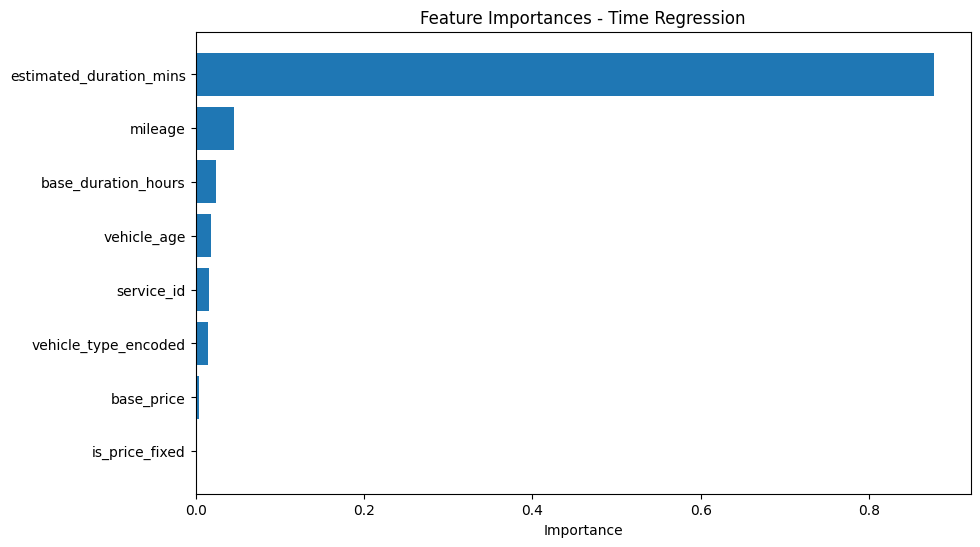

In [7]:
# Feature Importances
importances = rf_time.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print("\nFeature Importances:")
print(feat_imp_df)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importances - Time Regression')
plt.xlabel('Importance')
plt.show()


In [8]:
# Save predictions for the next step in the pipeline (Cost Model)
df['predicted_duration_mins'] = rf_time.predict(X_time)
df.to_csv('pipeline_time_output.csv', index=False)
print("Saved time predictions to pipeline_time_output.csv")


Saved time predictions to pipeline_time_output.csv

In [9]:
import joblib
joblib.dump(rf_time, 'exported/time_model.pkl')
joblib.dump(veh_type_encoder, 'exported/veh_type_encoder.pkl')
print("Exported: time_model.pkl, veh_type_encoder.pkl")


Exported: time_model.pkl, veh_type_encoder.pkl
